# `evaluation.ipynb` — Evaluación post-benchmark ERA5 T2M · Caribe

**Pre-requisito:** haber ejecutado `preprocessing.ipynb` y `modeling.ipynb`.

| Sección | Contenido |
|---|---|
| 1 | Carga de artefactos y generación de predicciones |
| 2 | Tabla maestra con IC bootstrap (ACC) y skill score |
| 3 | Diagnóstico de brecha Val→Test |
| 4 | Panel de series temporales — todos los modelos |
| 5 | Scatter observado vs predicho — candidatos principales |
| 6 | Diagnóstico de residuos — DW, normalidad, sesgo |
| 7 | ACC rodante (12 meses) — estabilidad temporal |
| 8 | Análisis por subperíodo climático (ENSO) |
| 9 | Tests estadísticos de diferencia entre modelos |
| 10 | Sesgo estacional por mes |
| 11 | Resumen ejecutivo y recomendaciones |

---

## 0. Imports y rutas

In [1]:
import os, json, pickle, warnings
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"]   = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats as sp_stats
from scipy.stats import ttest_rel
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow import keras
import xgboost as xgb
import warnings
warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)

plt.rcParams.update({
    "figure.dpi"       : 130,
    "axes.grid"        : True,
    "grid.alpha"       : 0.25,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
})

PREP_DIR   = Path("outputs_preprocessing")
MODELS_DIR = Path("outputs_models")
EVAL_DIR   = Path("outputs_evaluation")
EVAL_DIR.mkdir(exist_ok=True)

assert PREP_DIR.exists(),   f"Ejecutar preprocessing primero: {PREP_DIR}"
assert MODELS_DIR.exists(), f"Ejecutar modeling primero: {MODELS_DIR}"

print(f"TF: {tf.__version__}  |  XGB: {xgb.__version__}")
print(f"EVAL_DIR: {EVAL_DIR.resolve()}")

TF: 2.10.0  |  XGB: 2.1.4
EVAL_DIR: C:\Users\Hp\Documents\Seminario\docs\outputs_evaluation


## 1. Carga de artefactos y predicciones

In [2]:
# ── Artefactos del preprocesamiento ──────────────────────────────────────────
seqs        = np.load(PREP_DIR / "sequences.npz", allow_pickle=True)
X_train     = seqs["X_train"];  y_train = seqs["y_train"]
X_val       = seqs["X_val"];    y_val   = seqs["y_val"]
X_test      = seqs["X_test"];   y_test  = seqs["y_test"]
y_train_raw = seqs["y_train_raw"]
y_val_raw   = seqs["y_val_raw"]   # ← AGREGAR esta línea
y_test_raw  = seqs["y_test_raw"]

y_train_diff = seqs["y_train_diff"]
y_val_diff   = seqs["y_val_diff"]
y_test_diff  = seqs["y_test_diff"]

y_train_base_raw = seqs["y_train_base_raw"]
y_val_base_raw   = seqs["y_val_base_raw"]
y_test_base_raw  = seqs["y_test_base_raw"]

td_train = pd.to_datetime(seqs["target_dates_train"])
td_val   = pd.to_datetime(seqs["target_dates_val"])
td_test  = pd.to_datetime(seqs["target_dates_test"])

with open(PREP_DIR / "scaler_X.pkl", "rb") as f: scaler_X = pickle.load(f)
with open(PREP_DIR / "scaler_y.pkl", "rb") as f: scaler_y = pickle.load(f)
with open(PREP_DIR / "pipeline_metadata.json") as f: META = json.load(f)
with open(PREP_DIR / "scaler_y_diff.pkl", "rb") as f: scaler_y_diff = pickle.load(f)

HORIZON      = META["horizon"]
N_FEATURES   = META["n_features"]
FEATURE_COLS = META["feature_cols"]
TARGET       = META["target"]

with open(MODELS_DIR / "model_metadata.json") as f: META_MOD = json.load(f)
N_LAGS    = META_MOD["n_lags_seq"]
INPUT_SEQ = tuple(META_MOD["input_shape_seq"])
df_mod    = pd.read_csv(MODELS_DIR / "tabla_resultados.csv")

# ── Verificación crítica de consistencia ──────────────────────────────────────
npz_feats   = X_train.shape[1]
model_feats = INPUT_SEQ[1]  # (N_LAGS, N_FEATURES)
assert npz_feats == model_feats, (
    f"MISMATCH: .npz tiene {npz_feats} features pero "
    f"model_metadata espera {model_feats}. "
    f"Re-ejecutar regenerar_npz_roni.py y modeling.ipynb en orden."
)

print(f"HORIZON    : {HORIZON}m")
print(f"N_LAGS_SEQ : {N_LAGS}")
print(f"N_FEATURES : {N_FEATURES}  ({'OK' if N_FEATURES == npz_feats else 'MISMATCH'})")
print(f"X_train    : {X_train.shape}  → {td_train[0].date()} — {td_train[-1].date()}")
print(f"X_val      : {X_val.shape}    → {td_val[0].date()} — {td_val[-1].date()}")
print(f"X_test     : {X_test.shape}   → {td_test[0].date()} — {td_test[-1].date()}")

HORIZON    : 3m
N_LAGS_SEQ : 24
N_FEATURES : 44  (OK)
X_train    : (465, 44)  → 1977-04-01 — 2015-12-01
X_val      : (60, 44)    → 2016-01-01 — 2020-12-01
X_test     : (60, 44)   → 2021-01-01 — 2025-12-01


In [3]:
# ── Cargar modelos ────────────────────────────────────────────────────────────
def load_model(name):
    keras_p = MODELS_DIR / f"{name.lower().replace('-','_')}.keras"
    pkl_p   = MODELS_DIR / f"{name.lower()}.pkl"
    if keras_p.exists():
        return keras.models.load_model(keras_p, compile=False), "keras"
    if pkl_p.exists():
        with open(pkl_p, "rb") as f: return pickle.load(f), "sklearn"
    return None, None

DL_NAMES  = {"LSTM", "BiLSTM", "CNN-LSTM", "TCN"}
TAB_NAMES = {"Ridge", "Lasso", "XGBoost", "MLP"}

modelos = {}
for nombre in list(TAB_NAMES) + list(DL_NAMES):
    if nombre == "XGBoost":
        p = MODELS_DIR / "xgboost.json"
        if p.exists():
            m = xgb.XGBRegressor(); m.load_model(str(p))
            modelos[nombre] = (m, "sklearn")
    else:
        m, tipo = load_model(nombre)
        if m: modelos[nombre] = (m, tipo)

print("Modelos cargados:")
for n, (_, t) in modelos.items():
    print(f"  {n:<20} [{t}]")
print("\nVerificación de input shapes:")
for nombre, (m, tipo) in modelos.items():
    if tipo == "keras":
        print(f"  {nombre:<20} → {m.input_shape}")
    else:
        print(f"  {nombre:<20} → sklearn ({tipo})")

Modelos cargados:
  MLP                  [keras]
  Ridge                [sklearn]
  Lasso                [sklearn]
  CNN-LSTM             [keras]
  BiLSTM               [keras]
  TCN                  [keras]
  LSTM                 [keras]

Verificación de input shapes:
  MLP                  → (None, 44)
  Ridge                → sklearn (sklearn)
  Lasso                → sklearn (sklearn)
  CNN-LSTM             → (None, 24, 44)
  BiLSTM               → (None, 24, 44)
  TCN                  → (None, 24, 44)
  LSTM                 → (None, 24, 44)


In [4]:
# ── Reconstruir secuencias DL (idéntico a modeling.ipynb) ─────────────────────
X_full      = np.concatenate([X_train,         X_val,         X_test],         axis=0)
y_full_diff = np.concatenate([y_train_diff,     y_val_diff,    y_test_diff],    axis=0)
y_full_raw  = np.concatenate([y_train_raw, y_val_raw, y_test_raw], axis=0)
y_full_base = np.concatenate([y_train_base_raw, y_val_base_raw,y_test_base_raw],axis=0)

n_tr_full = len(X_train)
n_va_full = len(X_train) + len(X_val)

def build_sequences(Xf, yf, n_lags, horizon):
    Xo, yo, tidx = [], [], []
    for i in range(len(Xf) - n_lags - horizon + 1):
        Xo.append(Xf[i:i+n_lags])
        yo.append(yf[i+n_lags+horizon-1])
        tidx.append(i+n_lags+horizon-1)
    return (np.array(Xo, np.float32),
            np.array(yo, np.float32),
            np.array(tidx))

X_seq, y_seq_diff, tidx = build_sequences(X_full, y_full_diff, N_LAGS, HORIZON)

mask_te  = tidx >= n_va_full
X_te_seq = X_seq[mask_te]
y_te_seq = y_seq_diff[mask_te]

print(f"X_te_seq : {X_te_seq.shape}   (secuencias DL, test)")
print(f"X_test   : {X_test.shape}     (tabular, test)")

X_te_seq : (60, 24, 44)   (secuencias DL, test)
X_test   : (60, 44)     (tabular, test)


In [5]:
# Ejecutar en una celda nueva de cualquier notebook:
import numpy as np
from pathlib import Path

seqs = np.load("outputs_preprocessing/sequences.npz", allow_pickle=True)
print(f"X_train shape: {seqs['X_train'].shape}")
print(f"Claves disponibles: {sorted(seqs.files)}")
# Si dice (465, 40) → el .npz en disco es el viejo
# Si dice (465, 44) → el .npz es el nuevo con RONI

X_train shape: (465, 44)
Claves disponibles: ['X_test', 'X_train', 'X_val', 'target_dates_test', 'target_dates_train', 'target_dates_val', 'y_test', 'y_test_base_raw', 'y_test_diff', 'y_test_diff_raw', 'y_test_raw', 'y_train', 'y_train_base_raw', 'y_train_diff', 'y_train_diff_raw', 'y_train_raw', 'y_val', 'y_val_base_raw', 'y_val_diff', 'y_val_diff_raw', 'y_val_raw']


In [6]:
# ── Descalado ─────────────────────────────────────────────────────────────────
def descalar(y_sc):
    return scaler_y.inverse_transform(
        np.array(y_sc).reshape(-1,1)).ravel()

def descalar_diff(y_sc_diff):
    return scaler_y_diff.inverse_transform(
        np.array(y_sc_diff).reshape(-1,1)).ravel()

# ── Baselines ─────────────────────────────────────────────────────────────────
h = HORIZON
y_persist_test = np.concatenate([y_val[-h:], y_test[:-h]])[:len(y_test)]
y_zero_sc      = scaler_y.transform(np.zeros((len(y_test),1))).ravel()

# ── preds[nombre] = (y_true_K, y_pred_K, td_eje) — todo en escala real (K) ──
preds = {}

preds["Persistence"]  = (descalar(y_test), descalar(y_persist_test), td_test)
preds["Climatología"] = (descalar(y_test), descalar(y_zero_sc),      td_test)

# ── Tabulares: predicen nivel directamente con scaler_y ───────────────────────
for nombre in TAB_NAMES:
    if nombre not in modelos: continue
    m, _ = modelos[nombre]
    yp   = m.predict(X_test).flatten()
    preds[nombre] = (descalar(y_test), descalar(yp), td_test)

# ── DL: predicen Δy → reconstrucción base + diff ──────────────────────────────
for nombre in DL_NAMES:
    if nombre not in modelos: continue
    m, _ = modelos[nombre]
    yp_diff_sc = m.predict(X_te_seq, verbose=0).flatten()

    # Descalar la predicción diferencial
    yp_diff = descalar_diff(yp_diff_sc)

    # y_base: t2m(t) alineado con cada secuencia de test
    y_base = y_full_base[tidx[mask_te]]

    # Reconstruir anomalía absoluta predicha
    yp_abs = y_base + yp_diff

    # y_true: anomalía absoluta observada en t+3
    yt_abs = y_full_raw[tidx[mask_te]]

    # Fechas alineadas con las secuencias de test
    n_dl = len(yp_abs)
    t_dl = td_test[-n_dl:] if len(td_test) >= n_dl else pd.RangeIndex(n_dl)

    preds[nombre] = (yt_abs, yp_abs, t_dl)

print("Predicciones listas:",
      {k: len(v[0]) for k, v in preds.items()})

2/2 [==============================] - 1s 10ms/step
Predicciones listas: {'Persistence': 60, 'Climatología': 60, 'MLP': 60, 'Ridge': 60, 'Lasso': 60, 'CNN-LSTM': 60, 'BiLSTM': 60, 'TCN': 60, 'LSTM': 60}


## 2. Funciones de métricas

In [7]:
def acc_score(yt, yp):
    a = yt - yt.mean(); b = yp - yp.mean()
    return float(np.sum(a*b)/(np.sqrt(np.sum(a**2)*np.sum(b**2))+1e-10))

def full_metrics(yt, yp):
    return {
        "RMSE": float(np.sqrt(mean_squared_error(yt, yp))),
        "MAE" : float(mean_absolute_error(yt, yp)),
        "R2"  : float(r2_score(yt, yp)),
        "ACC" : acc_score(yt, yp),
        "Bias": float((yp-yt).mean()),
    }

def bootstrap_ci_acc(yt, yp, n=1000, seed=42):
    rng = np.random.default_rng(seed); ns = len(yt)
    accs = []
    for _ in range(n):
        idx = rng.integers(0, ns, ns)
        accs.append(acc_score(yt[idx], yp[idx]))
    return tuple(np.percentile(accs, [2.5, 97.5]))

def safe_taxis(nombre, n):
    """Eje temporal seguro: siempre len==n."""
    t = preds[nombre][2]
    if isinstance(t, pd.DatetimeIndex) and len(t) >= n:
        return t[:n]
    return np.arange(n)

print("Métricas definidas")

Métricas definidas


## 3. Tabla maestra con IC bootstrap y skill score

In [8]:
yt_pers, yp_pers, _ = preds["Persistence"]
acc_pers = acc_score(yt_pers, yp_pers)

rows = []
for nombre, (yt_r, yp_r, _) in preds.items():
    m   = full_metrics(yt_r, yp_r)
    lo, hi = bootstrap_ci_acc(yt_r, yp_r)
    ss  = 1.0 - (1.0 - m["ACC"]) / (1.0 - acc_pers + 1e-10)
    fam = ("Baseline" if nombre in {"Persistence","Climatología"}
           else "Tabular" if nombre in TAB_NAMES
           else "DL-Sec.")
    rows.append({
        "Modelo"              : nombre,
        "Familia"             : fam,
        "RMSE (K)"            : round(m["RMSE"], 4),
        "MAE (K)"             : round(m["MAE"],  4),
        "R²"                  : round(m["R2"],   4),
        "ACC"                 : round(m["ACC"],  4),
        "IC 95% ACC"          : f"[{lo:.3f}, {hi:.3f}]",
        "Skill vs Persistence": round(ss, 4),
        "Sesgo (K)"           : round(m["Bias"], 4),
    })

df_eval = (pd.DataFrame(rows)
             .sort_values("ACC", ascending=False)
             .reset_index(drop=True))
df_eval.to_csv(EVAL_DIR / "metricas_test.csv", index=False)
df_eval

,Modelo,Familia,RMSE (K),MAE (K),R²,ACC,IC 95% ACC,Skill vs Persistence,Sesgo (K)
0,Ridge,Tabular,0.3610,0.2604,0.5032,0.7783,"[0.683, 0.861]",0.1612,-0.1462
1,Lasso,Tabular,0.4677,0.3641,0.1660,0.7695,"[0.668, 0.855]",0.1278,-0.3004
2,LSTM,DL-Sec.,0.3481,0.2768,0.5379,0.7553,"[0.649, 0.834]",0.0741,0.0131
3,BiLSTM,DL-Sec.,0.3441,0.2766,0.5484,0.7529,"[0.646, 0.830]",0.0649,0.0015
4,MLP,Tabular,0.3830,0.2816,0.4407,0.7433,"[0.644, 0.829]",0.0286,-0.1427
5,TCN,DL-Sec.,0.3514,0.2749,0.5292,0.7420,"[0.636, 0.822]",0.0239,-0.0394
6,CNN-LSTM,DL-Sec.,0.3684,0.2927,0.4826,0.7388,"[0.624, 0.824]",0.0118,0.0190
7,Persistence,Baseline,0.3746,0.2936,0.4649,0.7357,"[0.618, 0.823]",0.0000,-0.0168
8,Climatología,Baseline,0.9622,0.8161,-2.5301,0.0000,"[0.000, 0.000]",-2.7839,-0.8146


## 4. Diagnóstico de brecha Val→Test

Cruza las métricas de Val de `modeling.ipynb` con las de Test calculadas aquí.  
Brecha > 0.15 en ACC → sobreajuste o dependencia del período de test.

In [9]:
df_gap = df_mod[["Modelo","Val-ACC","Val-RMSE (K)",
                 "Test-RMSE (K)","Test-ACC"]].copy()
df_gap = df_gap.merge(
    df_eval[["Modelo","ACC","Sesgo (K)"]].rename(
        columns={"ACC":"Test-ACC-eval"}),
    on="Modelo", how="inner"
)
df_gap["Brecha Val→Test"] = (df_gap["Test-ACC-eval"]-df_gap["Val-ACC"]).round(4)

def clasificar(b):
    if abs(b) < 0.15: return "Alta"
    if abs(b) < 0.30: return "Media"
    return "Baja"

df_gap["Confiabilidad"] = df_gap["Brecha Val→Test"].apply(clasificar)
df_gap = df_gap.sort_values("Test-ACC-eval", ascending=False).reset_index(drop=True)
df_gap.to_csv(EVAL_DIR / "brecha_val_test.csv", index=False)
print(df_gap[["Modelo","Test-ACC-eval",
              "Brecha Val→Test","Confiabilidad","Sesgo (K)"]].to_string(index=False))

      Modelo  Test-ACC-eval  Brecha Val→Test Confiabilidad  Sesgo (K)
       Ridge         0.7783           0.1033          Alta    -0.1462
       Lasso         0.7695           0.1502         Media    -0.3004
        LSTM         0.7553           0.3492          Baja     0.0131
      BiLSTM         0.7529           0.2759         Media     0.0015
         MLP         0.7433           0.1324          Alta    -0.1427
         TCN         0.7420           0.2735         Media    -0.0394
    CNN-LSTM         0.7388           0.2805         Media     0.0190
 Persistence         0.7357           0.2858         Media    -0.0168
Climatología         0.0000           0.0000          Alta    -0.8146


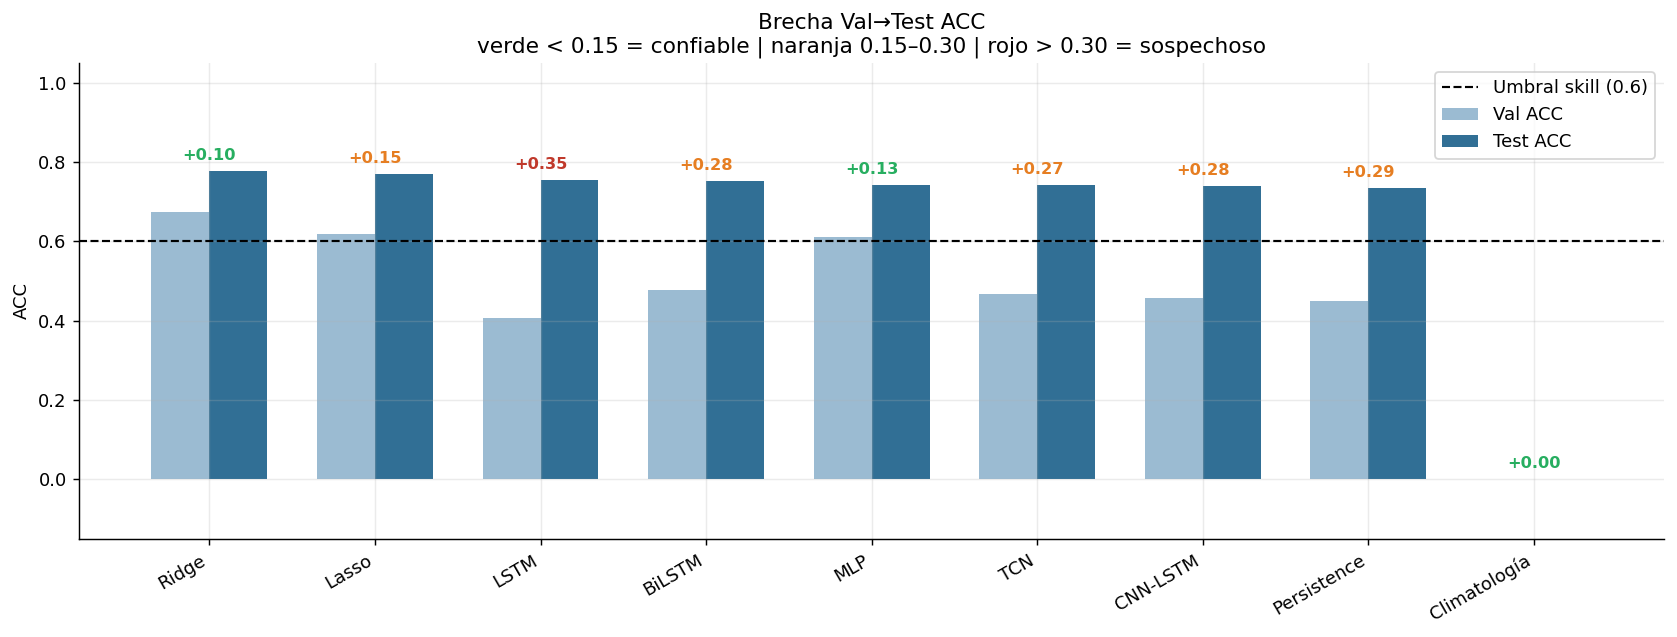

In [10]:
# Visualización brecha
orden    = df_gap["Modelo"].tolist()
val_acc  = df_gap["Val-ACC"].values
test_acc = df_gap["Test-ACC-eval"].values
brechas  = df_gap["Brecha Val→Test"].values
x = np.arange(len(orden)); w = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - w/2, val_acc,  w, label="Val ACC",  color="#90b4ce", alpha=0.9)
ax.bar(x + w/2, test_acc, w, label="Test ACC", color="#1a5f8a", alpha=0.9)

for i, (va, te, br) in enumerate(zip(val_acc, test_acc, brechas)):
    col = ("#c0392b" if abs(br) >= 0.30 else
           "#e67e22" if abs(br) >= 0.15 else "#27ae60")
    ax.annotate(f"{br:+.2f}", xy=(x[i], max(va,te)+0.02),
                ha="center", va="bottom", fontsize=9,
                fontweight="bold", color=col)

ax.axhline(0.6, color="black", linestyle="--", linewidth=1.2,
           label="Umbral skill (0.6)")
ax.set_xticks(x); ax.set_xticklabels(orden, rotation=30, ha="right")
ax.set_ylabel("ACC"); ax.set_ylim(-0.15, 1.05)
ax.set_title("Brecha Val→Test ACC\n"
             "verde < 0.15 = confiable | naranja 0.15–0.30 | rojo > 0.30 = sospechoso")
ax.legend()
plt.tight_layout()
plt.savefig(EVAL_DIR / "brecha_val_test.png", dpi=150)
plt.show()

## 5. Panel de series temporales

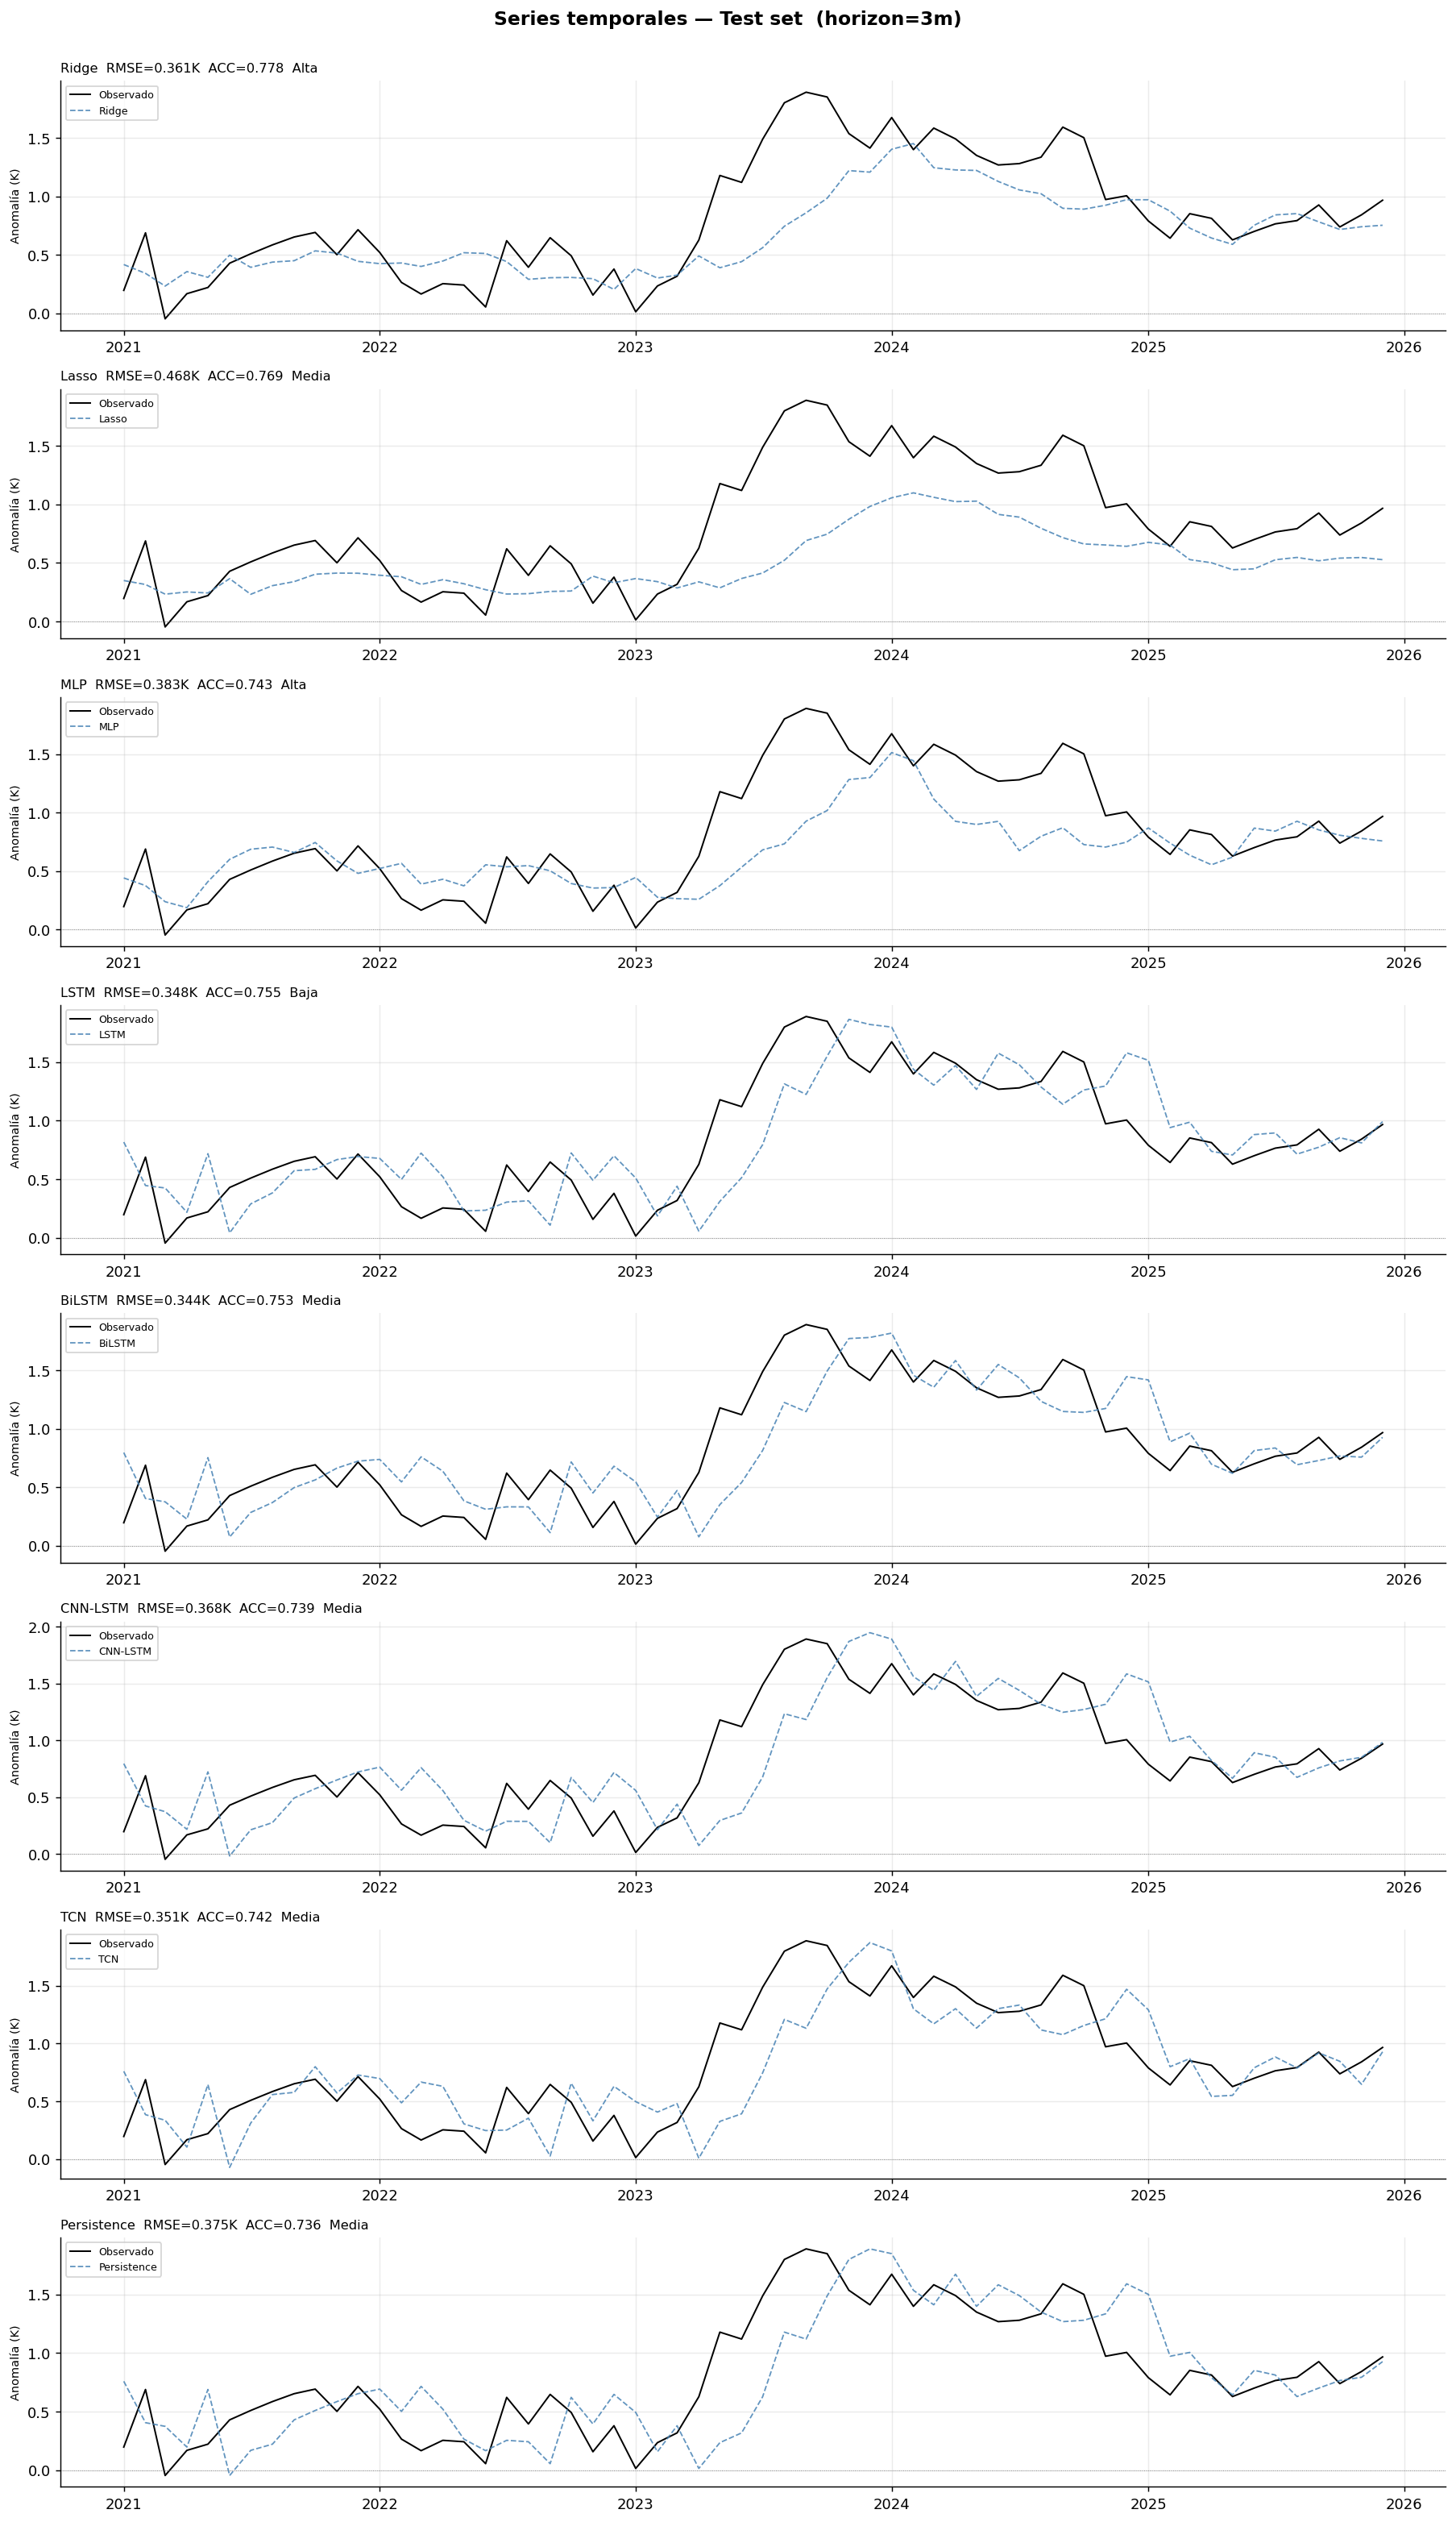

In [11]:
panel = [n for n in ["Ridge","Lasso","XGBoost","MLP",
                     "LSTM","StackedLSTM","BiLSTM","CNN-LSTM","TCN",
                     "Persistence"] if n in preds]

conf_map   = dict(zip(df_gap["Modelo"], df_gap["Confiabilidad"]))
color_conf = {"Alta ":"#2980b9", "Media ⚠":"#e67e22", "Baja ✗":"#c0392b"}

fig, axes = plt.subplots(len(panel), 1,
                         figsize=(14, 3.0*len(panel)), sharex=False)

for ax, nombre in zip(axes, panel):
    yt_r, yp_r, _ = preds[nombre]
    n   = min(len(yt_r), len(yp_r))
    t   = safe_taxis(nombre, n)
    a   = acc_score(yt_r[:n], yp_r[:n])
    r   = float(np.sqrt(mean_squared_error(yt_r[:n], yp_r[:n])))
    col = color_conf.get(conf_map.get(nombre,""), "steelblue")

    ax.plot(t, yt_r[:n], color="black", linewidth=1.1, label="Observado")
    ax.plot(t, yp_r[:n], color=col,     linewidth=1.0,
            linestyle="--", label=nombre, alpha=0.85)
    ax.axhline(0, color="gray", linewidth=0.5, linestyle=":")
    ax.set_ylabel("Anomalía (K)", fontsize=8)
    ax.set_title(f"{nombre}  RMSE={r:.3f}K  ACC={a:.3f}  "
                 f"{conf_map.get(nombre,'')}", fontsize=9, loc="left")
    ax.legend(fontsize=7, loc="upper left")

fig.suptitle(f"Series temporales — Test set  (horizon={HORIZON}m)",
             fontsize=13, fontweight="bold", y=1.001)
plt.tight_layout()
plt.savefig(EVAL_DIR / "series_temporales_panel.png",
            dpi=120, bbox_inches="tight")
plt.show()

## 6. Scatter observado vs predicho — candidatos principales

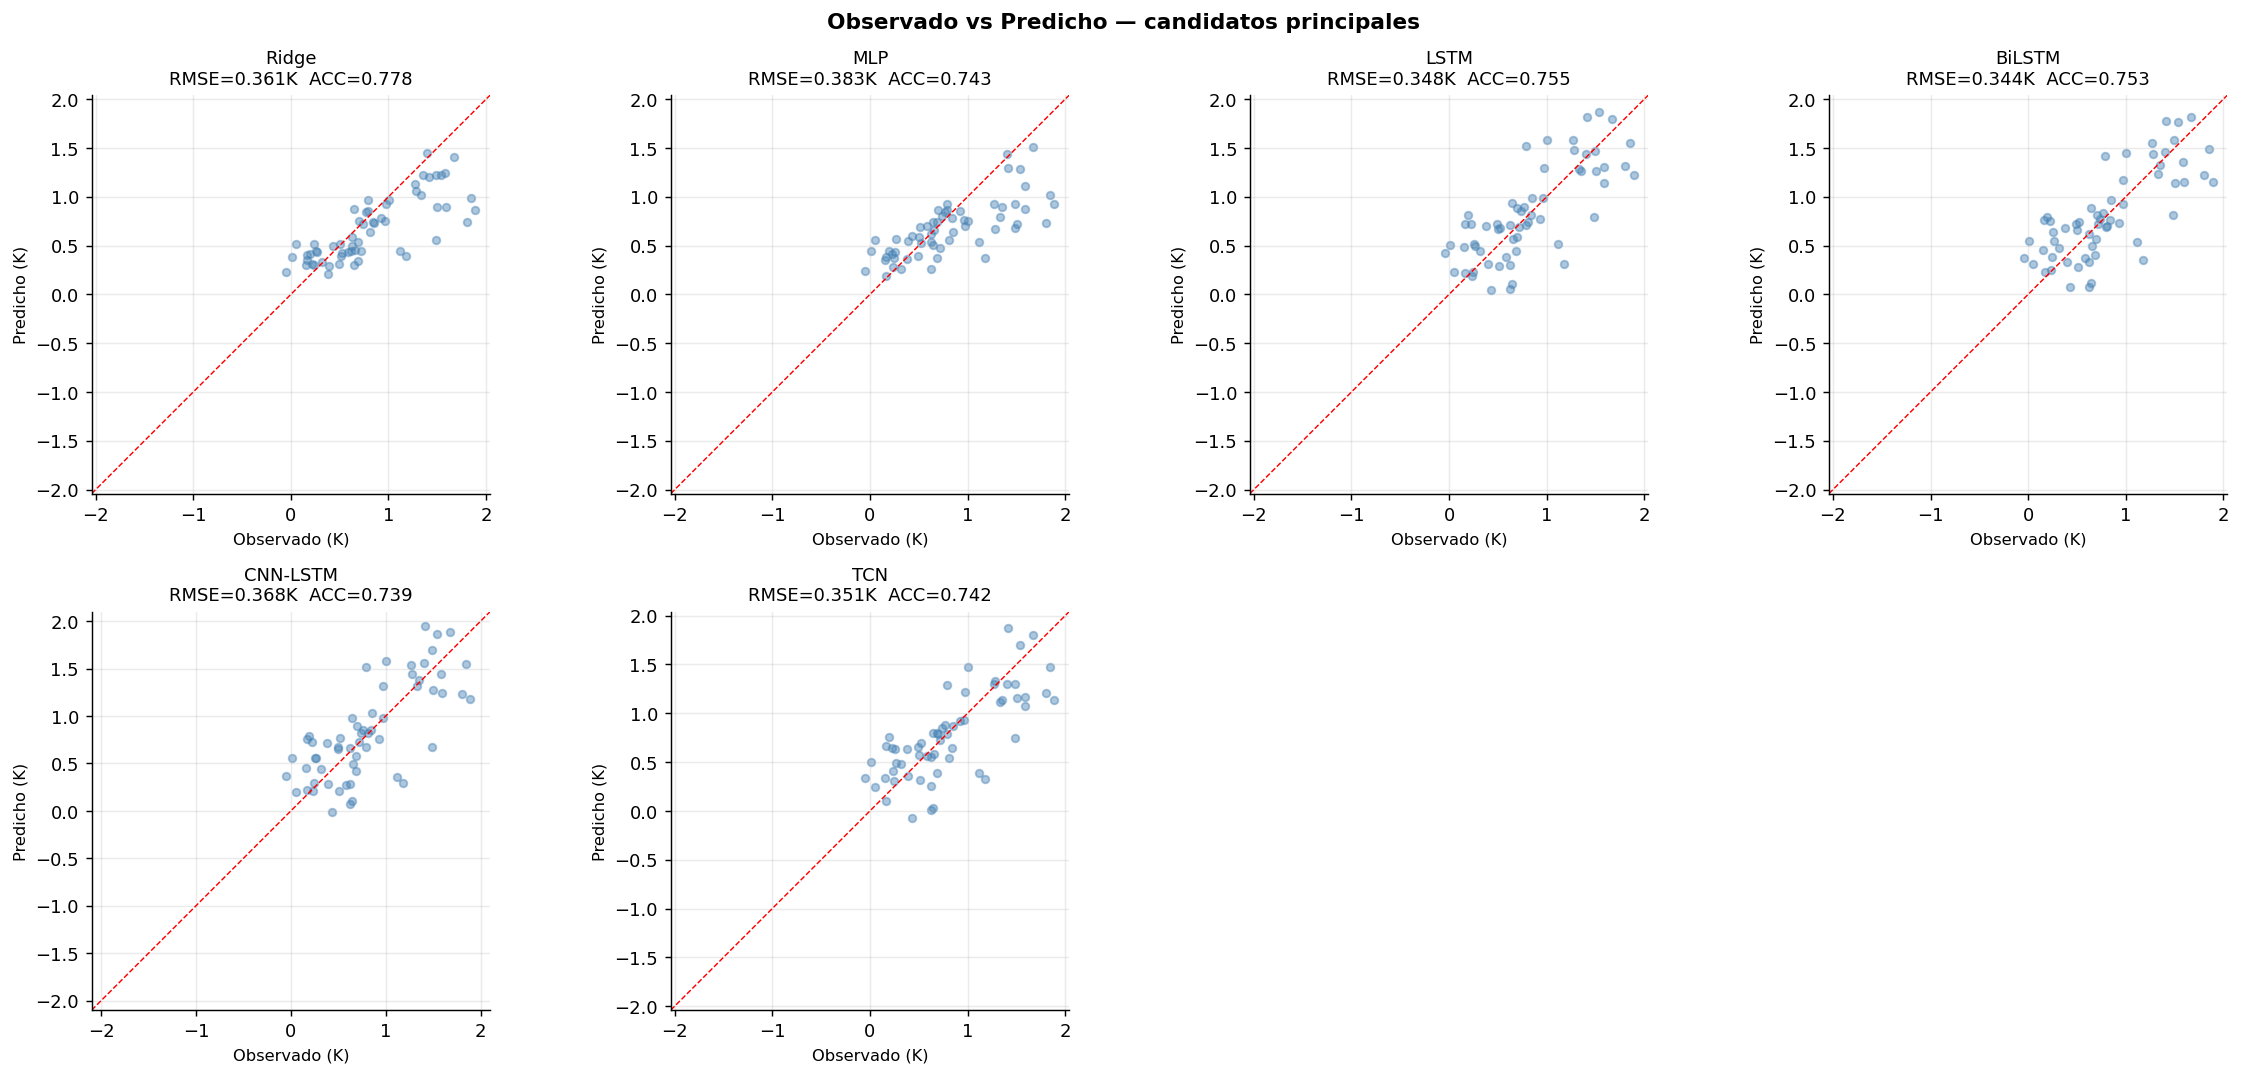

In [12]:
candidatos = [n for n in ["Ridge","XGBoost","MLP",
                           "LSTM","BiLSTM","CNN-LSTM","TCN"]
              if n in preds]

ncols = min(4, len(candidatos))
nrows = (len(candidatos) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols,
                         figsize=(4.5*ncols, 4.2*nrows), squeeze=False)

for ax, nombre in zip(axes.ravel(), candidatos):
    yt_r, yp_r, _ = preds[nombre]
    n   = min(len(yt_r), len(yp_r))
    a   = acc_score(yt_r[:n], yp_r[:n])
    r   = float(np.sqrt(mean_squared_error(yt_r[:n], yp_r[:n])))
    lim = max(abs(yt_r[:n]).max(), abs(yp_r[:n]).max()) * 1.08
    ax.scatter(yt_r[:n], yp_r[:n], alpha=0.45, s=18, color="steelblue")
    ax.plot([-lim,lim], [-lim,lim], "r--", linewidth=0.8)
    ax.set_xlim(-lim,lim); ax.set_ylim(-lim,lim); ax.set_aspect("equal")
    ax.set_xlabel("Observado (K)", fontsize=9)
    ax.set_ylabel("Predicho (K)",  fontsize=9)
    ax.set_title(f"{nombre}\nRMSE={r:.3f}K  ACC={a:.3f}", fontsize=10)

for ax in axes.ravel()[len(candidatos):]:
    ax.set_visible(False)

fig.suptitle("Observado vs Predicho — candidatos principales",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(EVAL_DIR / "scatter_obs_pred.png", dpi=150)
plt.show()

## 7. Diagnóstico de residuos — DW, normalidad, sesgo

Ridge           DW=0.517  p_norm=0.001  sesgo=-0.1462K  autocorr ALTA
LSTM            DW=0.988  p_norm=0.626  sesgo=+0.0131K  autocorr ALTA
BiLSTM          DW=0.959  p_norm=0.357  sesgo=+0.0015K  autocorr ALTA
CNN-LSTM        DW=0.845  p_norm=0.165  sesgo=+0.0190K  autocorr ALTA
TCN             DW=0.958  p_norm=0.049  sesgo=-0.0394K  autocorr ALTA


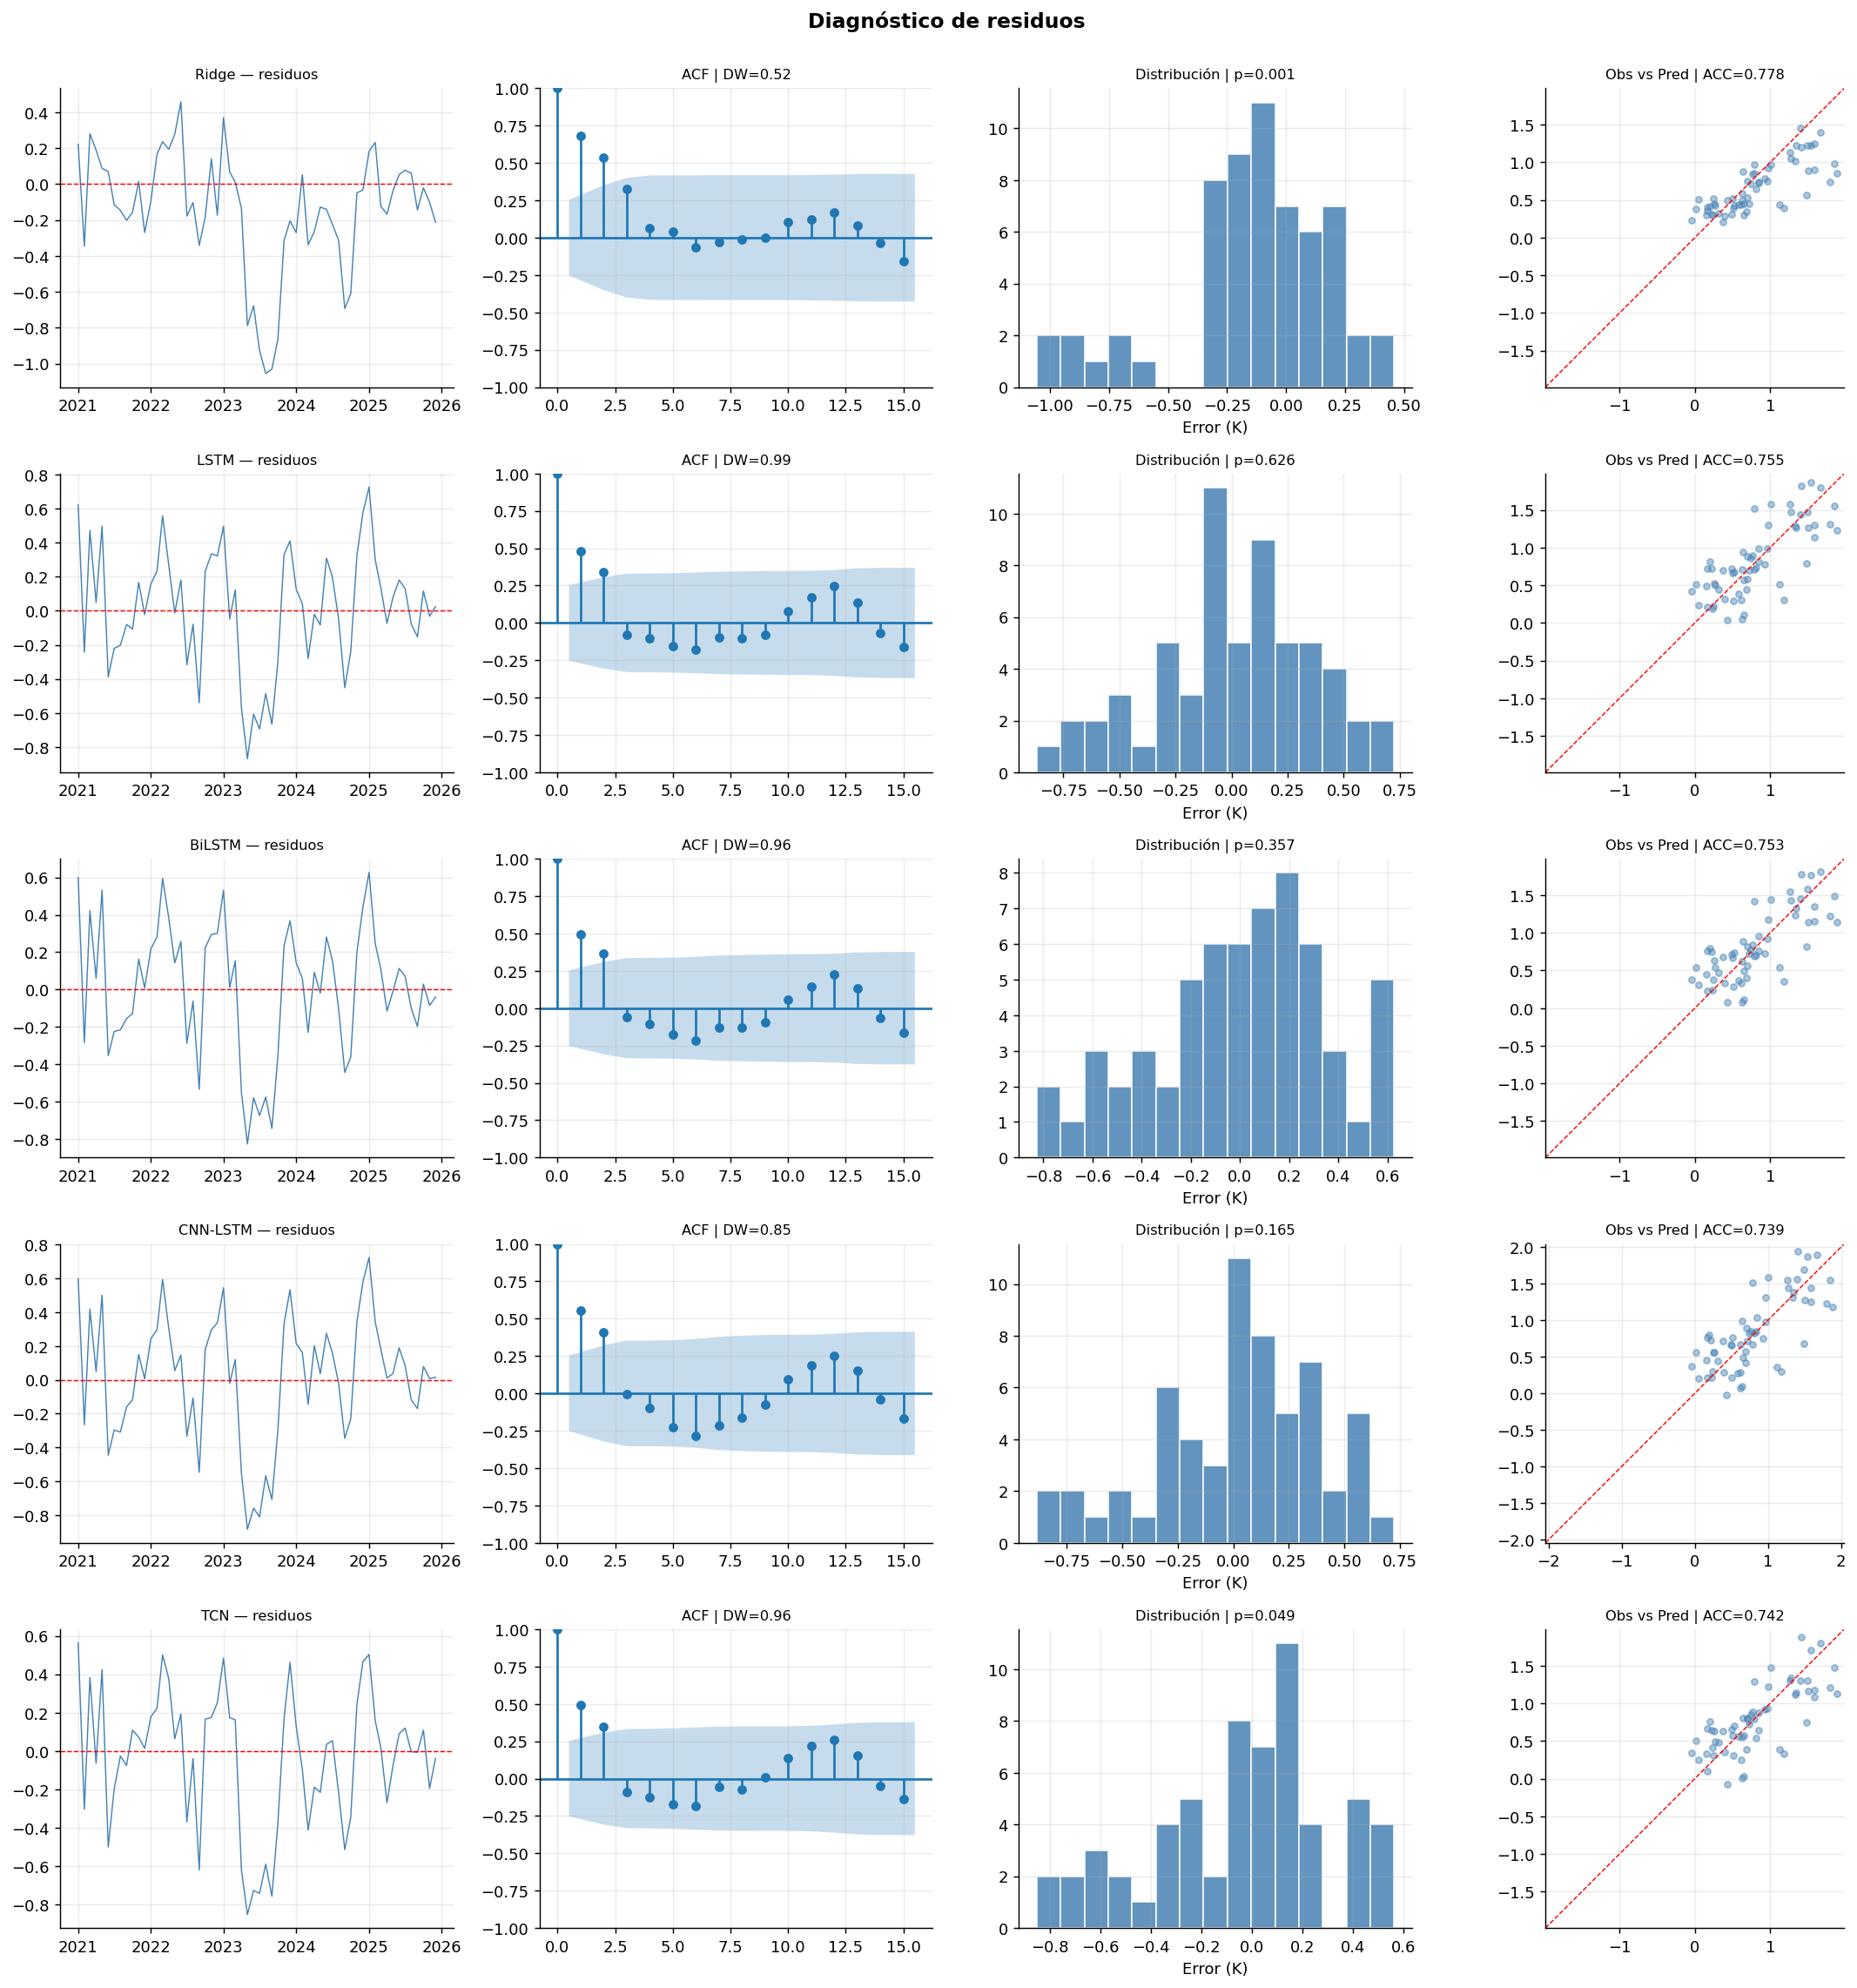

,Modelo,DW,Autocorr,p_norm,Normal(5%),Sesgo (K)
0,Ridge,0.517,Alta,0.0007,No,-0.1462
1,LSTM,0.988,Alta,0.6260,Sí,0.0131
2,BiLSTM,0.959,Alta,0.3566,Sí,0.0015
3,CNN-LSTM,0.845,Alta,0.1655,Sí,0.0190
4,TCN,0.958,Alta,0.0489,No,-0.0394


In [13]:
diag_nombres = [n for n in ["Ridge","XGBoost","LSTM",
                             "BiLSTM","CNN-LSTM","TCN"]
                if n in preds]

rows_dw = []
fig, axes = plt.subplots(len(diag_nombres), 4,
                         figsize=(17, 3.5*len(diag_nombres)))

for i, nombre in enumerate(diag_nombres):
    yt_r, yp_r, _ = preds[nombre]
    n  = min(len(yt_r), len(yp_r))
    yt = yt_r[:n]; yp = yp_r[:n]; res = yp - yt

    dw        = durbin_watson(res)
    _, p_norm = sp_stats.shapiro(res[:min(len(res), 500)])
    sesgo     = float(res.mean())

    rows_dw.append({
        "Modelo"     : nombre,
        "DW"         : round(dw, 3),
        "Autocorr"   : "Alta" if dw < 1.5 else ("Media" if dw < 1.8 else "Baja"),
        "p_norm"     : round(p_norm, 4),
        "Normal(5%)" : "Sí" if p_norm > 0.05 else "No",
        "Sesgo (K)"  : round(sesgo, 4),
    })

    t_ax = safe_taxis(nombre, n)

    axes[i,0].plot(t_ax, res, linewidth=0.8, color="steelblue")
    axes[i,0].axhline(0, color="red", linewidth=0.8, linestyle="--")
    axes[i,0].set_title(f"{nombre} — residuos", fontsize=9)

    plot_acf(res, lags=min(20, n//4), ax=axes[i,1], alpha=0.05)
    axes[i,1].set_title(f"ACF | DW={dw:.2f}", fontsize=9)

    axes[i,2].hist(res, bins=15, color="steelblue", edgecolor="white", alpha=0.85)
    axes[i,2].set_title(f"Distribución | p={p_norm:.3f}", fontsize=9)
    axes[i,2].set_xlabel("Error (K)")

    lim = max(abs(yt).max(), abs(yp).max()) * 1.05
    axes[i,3].scatter(yt, yp, alpha=0.45, s=16, color="steelblue")
    axes[i,3].plot([-lim,lim], [-lim,lim], "r--", linewidth=0.8)
    axes[i,3].set_xlim(-lim,lim); axes[i,3].set_ylim(-lim,lim)
    axes[i,3].set_aspect("equal")
    axes[i,3].set_title(f"Obs vs Pred | ACC={acc_score(yt,yp):.3f}", fontsize=9)

    print(f"{nombre:15s} DW={dw:.3f}  p_norm={p_norm:.3f}  "
          f"sesgo={sesgo:+.4f}K  "
          f"{'autocorr ALTA' if dw < 1.5 else 'DW OK'}")

plt.suptitle("Diagnóstico de residuos",
             fontsize=13, fontweight="bold", y=1.001)
plt.tight_layout()
plt.savefig(EVAL_DIR / "diagnostico_residuos.png",
            dpi=120, bbox_inches="tight")
plt.show()

df_dw = pd.DataFrame(rows_dw)
df_dw.to_csv(EVAL_DIR / "diagnostico_residuos.csv", index=False)
df_dw

## 8. ACC rodante (12 meses) — estabilidad temporal

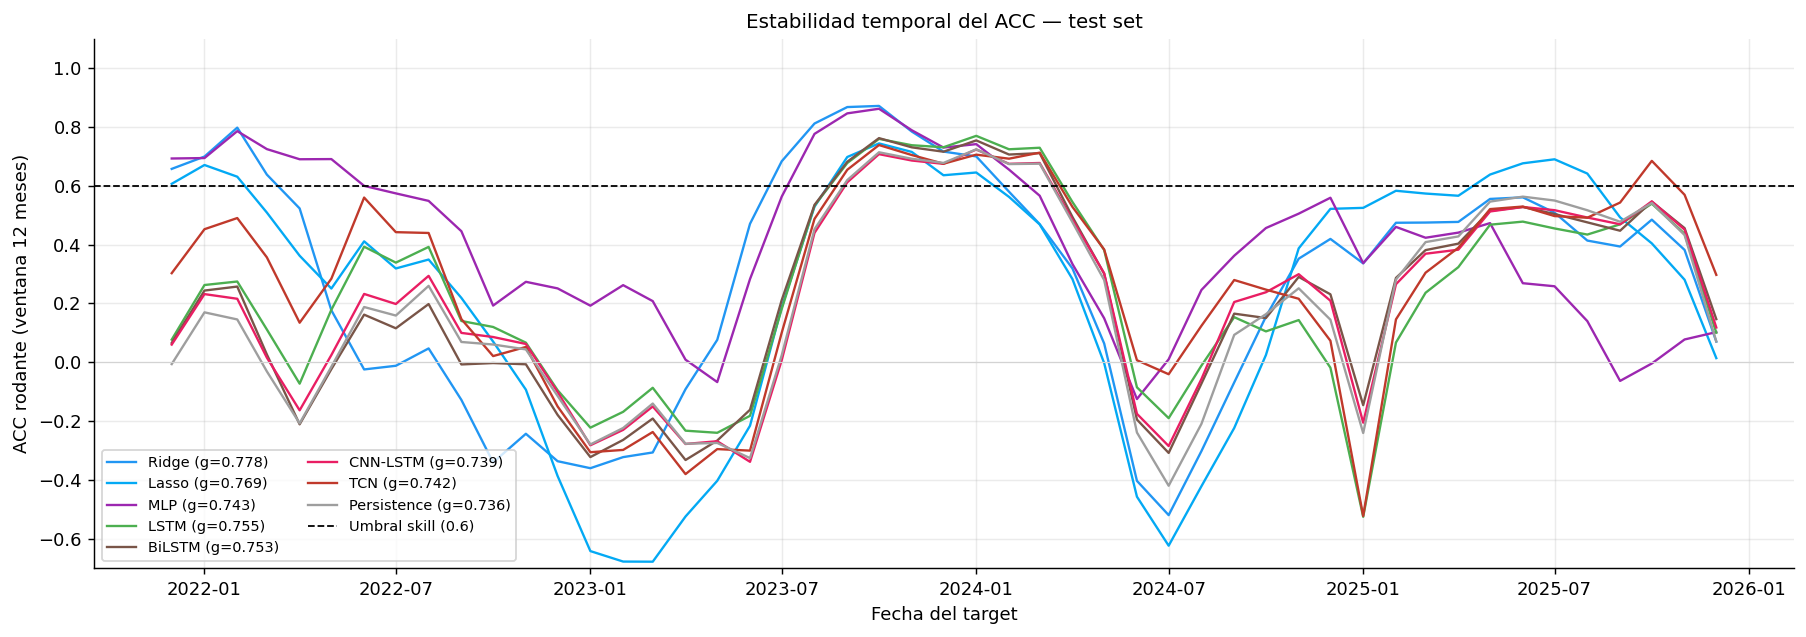

In [14]:
def rolling_acc(yt, yp, window=12):
    out = [np.nan] * (window-1)
    for i in range(window-1, len(yt)):
        out.append(acc_score(yt[i-window+1:i+1], yp[i-window+1:i+1]))
    return np.array(out)

PALETTE = {
    "Ridge":"#2196F3", "Lasso":"#03A9F4", "XGBoost":"#FF9800", "MLP":"#9C27B0",
    "LSTM":"#4CAF50", "StackedLSTM":"#009688", "BiLSTM":"#795548",
    "CNN-LSTM":"#E91E63", "TCN":"#c0392b", "Persistence":"#9E9E9E",
}

fig, ax = plt.subplots(figsize=(14, 5))

for nombre, color in PALETTE.items():
    if nombre not in preds: continue
    yt_r, yp_r, _ = preds[nombre]
    n  = min(len(yt_r), len(yp_r))
    ra = rolling_acc(yt_r[:n], yp_r[:n], window=12)
    t  = safe_taxis(nombre, n)
    ax.plot(t, ra, label=f"{nombre} (g={acc_score(yt_r[:n],yp_r[:n]):.3f})",
            color=color, linewidth=1.3)

ax.axhline(0.6, color="black", linestyle="--", linewidth=1.0,
           label="Umbral skill (0.6)")
ax.axhline(0.0, color="lightgray", linewidth=0.6)
ax.set_ylabel("ACC rodante (ventana 12 meses)")
ax.set_xlabel("Fecha del target")
ax.set_title("Estabilidad temporal del ACC — test set", fontsize=11)
ax.legend(fontsize=8, loc="lower left", ncol=2)
ax.set_ylim(-0.7, 1.1)
plt.tight_layout()
plt.savefig(EVAL_DIR / "rolling_acc.png", dpi=150)
plt.show()

## 9. Análisis por subperíodo climático (ENSO)

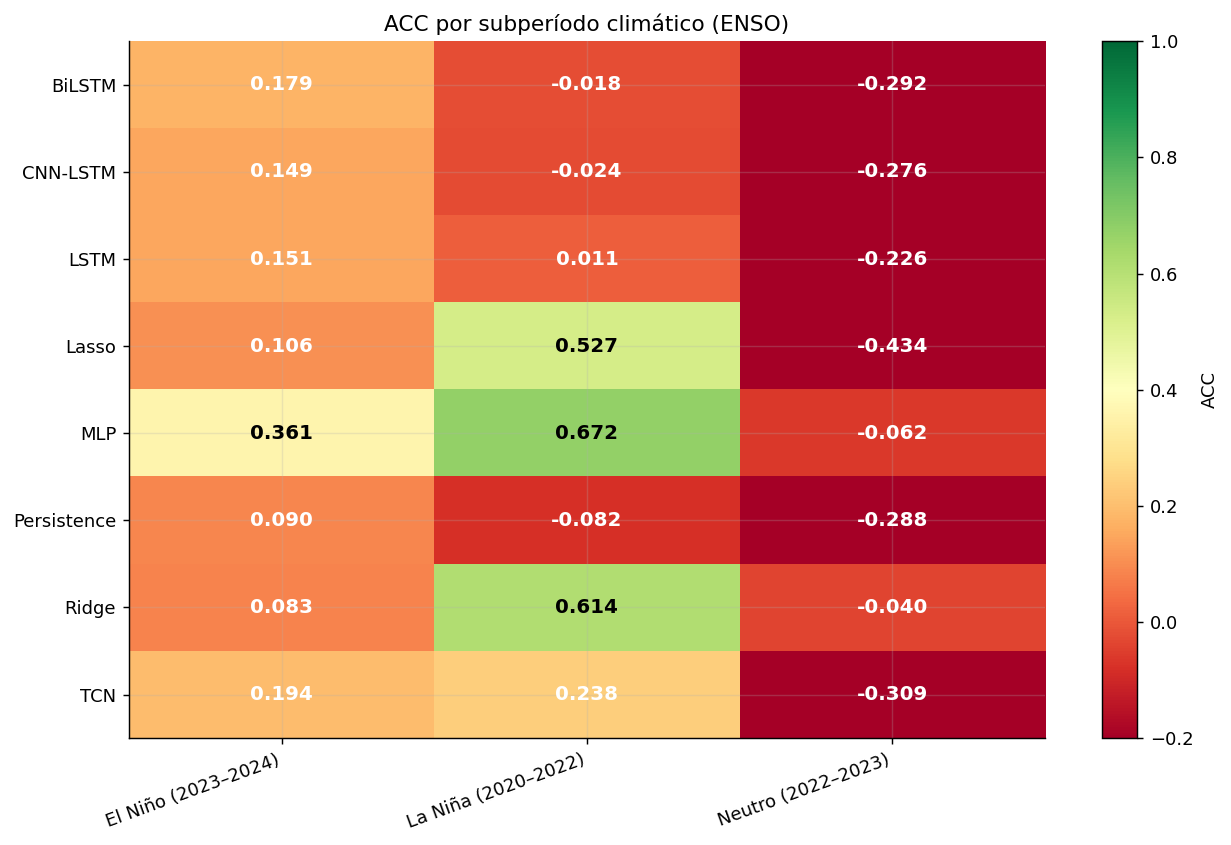

Período      El Niño (2023–2024)  La Niña (2020–2022)  Neutro (2022–2023)
Modelo                                                                   
BiLSTM                     0.179               -0.018              -0.292
CNN-LSTM                   0.149               -0.024              -0.276
LSTM                       0.151                0.011              -0.226
Lasso                      0.106                0.527              -0.434
MLP                        0.361                0.672              -0.062
Persistence                0.090               -0.082              -0.288
Ridge                      0.083                0.614              -0.040
TCN                        0.194                0.238              -0.309


In [15]:
# Ajusta estas fechas según tu test set real
subperiodos = {
    "La Niña (2020–2022)" : ("2020-09", "2022-03"),
    "Neutro (2022–2023)"  : ("2022-04", "2023-05"),
    "El Niño (2023–2024)" : ("2023-06", "2024-12"),
}

# ── CAMBIO: agregar TCN y MLP ─────────────────────────────────────────────────
sub_nombres = [n for n in ["Ridge", "Lasso", "XGBoost", "MLP",
                            "LSTM", "BiLSTM", "CNN-LSTM", "TCN", "Persistence"]
               if n in preds]

# el resto de la celda queda exactamente igual
rows_sub = []
for nombre in sub_nombres:
    yt_r, yp_r, t_ax_raw = preds[nombre]
    n = min(len(yt_r), len(yp_r))
    if (not isinstance(t_ax_raw, pd.DatetimeIndex)
            or len(t_ax_raw) < n):
        continue
    t_idx = t_ax_raw[:n]
    for periodo, (t0, t1) in subperiodos.items():
        mask = (t_idx >= t0) & (t_idx <= t1)
        if mask.sum() < 3: continue
        rows_sub.append({
            "Modelo" : nombre,
            "Período": periodo,
            "n"      : int(mask.sum()),
            "RMSE"   : round(float(np.sqrt(mean_squared_error(
                             yt_r[:n][mask], yp_r[:n][mask]))), 4),
            "ACC"    : round(acc_score(yt_r[:n][mask], yp_r[:n][mask]), 4),
        })
if rows_sub:
    df_sub = pd.DataFrame(rows_sub)
    df_sub.to_csv(EVAL_DIR / "metricas_subperiodos.csv", index=False)
    pivot  = df_sub.pivot_table(index="Modelo", columns="Período",
                                values="ACC").round(3)
    fig, ax = plt.subplots(figsize=(10, max(3, len(pivot)*0.7+1)))
    data = pivot.values
    im   = ax.imshow(data, aspect="auto", cmap="RdYlGn", vmin=-0.2, vmax=1.0)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=20, ha="right")
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    for r in range(data.shape[0]):
        for c in range(data.shape[1]):
            v = data[r,c]
            ax.text(c, r, f"{v:.3f}", ha="center", va="center",
                    fontsize=11, fontweight="bold",
                    color="white" if v < 0.3 else "black")
    plt.colorbar(im, ax=ax, label="ACC")
    ax.set_title("ACC por subperíodo climático (ENSO)", fontsize=12)
    plt.tight_layout()
    plt.savefig(EVAL_DIR / "heatmap_subperiodos.png", dpi=150)
    plt.show()
    print(pivot.to_string())
else:
    print(f"Sin superposición entre td_test ({td_test[0].date()}–{td_test[-1].date()})")
    print("y los subperíodos definidos. Ajusta las fechas de 'subperiodos' arriba.")

## 10. Tests estadísticos — ¿las diferencias son significativas?

In [16]:
pares = [(a,b) for a,b in [
    ("Ridge","LSTM"), ("Ridge","BiLSTM"), ("Ridge","CNN-LSTM"),
    ("Ridge","TCN"),  ("Ridge","XGBoost"), ("Ridge","Persistence"),
    ("LSTM","BiLSTM"),("BiLSTM","CNN-LSTM"),("CNN-LSTM","TCN"),
] if a in preds and b in preds]

print(f"{'Comparación':<30} {'t':>7} {'p':>9} {'Sig':>5}  Mejor")
print("-"*68)

rows_t = []
for m1, m2 in pares:
    yt1,yp1,_ = preds[m1]; yt2,yp2,_ = preds[m2]
    n = min(len(yt1),len(yp1),len(yt2),len(yp2))
    e1 = np.abs(yp1[:n]-yt1[:n])
    e2 = np.abs(yp2[:n]-yt2[:n])
    t_s, p_v = ttest_rel(e1, e2)
    sig  = "***" if p_v<0.01 else "**" if p_v<0.05 else "*" if p_v<0.10 else "ns"
    best = m1 if e1.mean() < e2.mean() else m2
    lbl  = f"{m1} vs {m2}"
    print(f"  {lbl:<28} {t_s:+7.3f} {p_v:9.4f} {sig:>5}  → {best}")
    rows_t.append({"Par":lbl,"t":round(t_s,3),"p":round(p_v,4),"Sig":sig,"Mejor":best})

print("\n  *** p<0.01   ** p<0.05   * p<0.10   ns = no significativo")
pd.DataFrame(rows_t).to_csv(EVAL_DIR / "tests_estadisticos.csv", index=False)

Comparación                          t         p   Sig  Mejor
--------------------------------------------------------------------
  Ridge vs LSTM                 -0.543    0.5889    ns  → Ridge
  Ridge vs BiLSTM               -0.610    0.5443    ns  → Ridge
  Ridge vs CNN-LSTM             -1.059    0.2937    ns  → Ridge
  Ridge vs TCN                  -0.548    0.5856    ns  → Ridge
  Ridge vs Persistence          -1.122    0.2666    ns  → Ridge
  LSTM vs BiLSTM                +0.024    0.9808    ns  → BiLSTM
  BiLSTM vs CNN-LSTM            -1.742    0.0868     *  → BiLSTM
  CNN-LSTM vs TCN               +1.191    0.2382    ns  → TCN

  *** p<0.01   ** p<0.05   * p<0.10   ns = no significativo


## 11. Sesgo estacional — MAE por mes del año

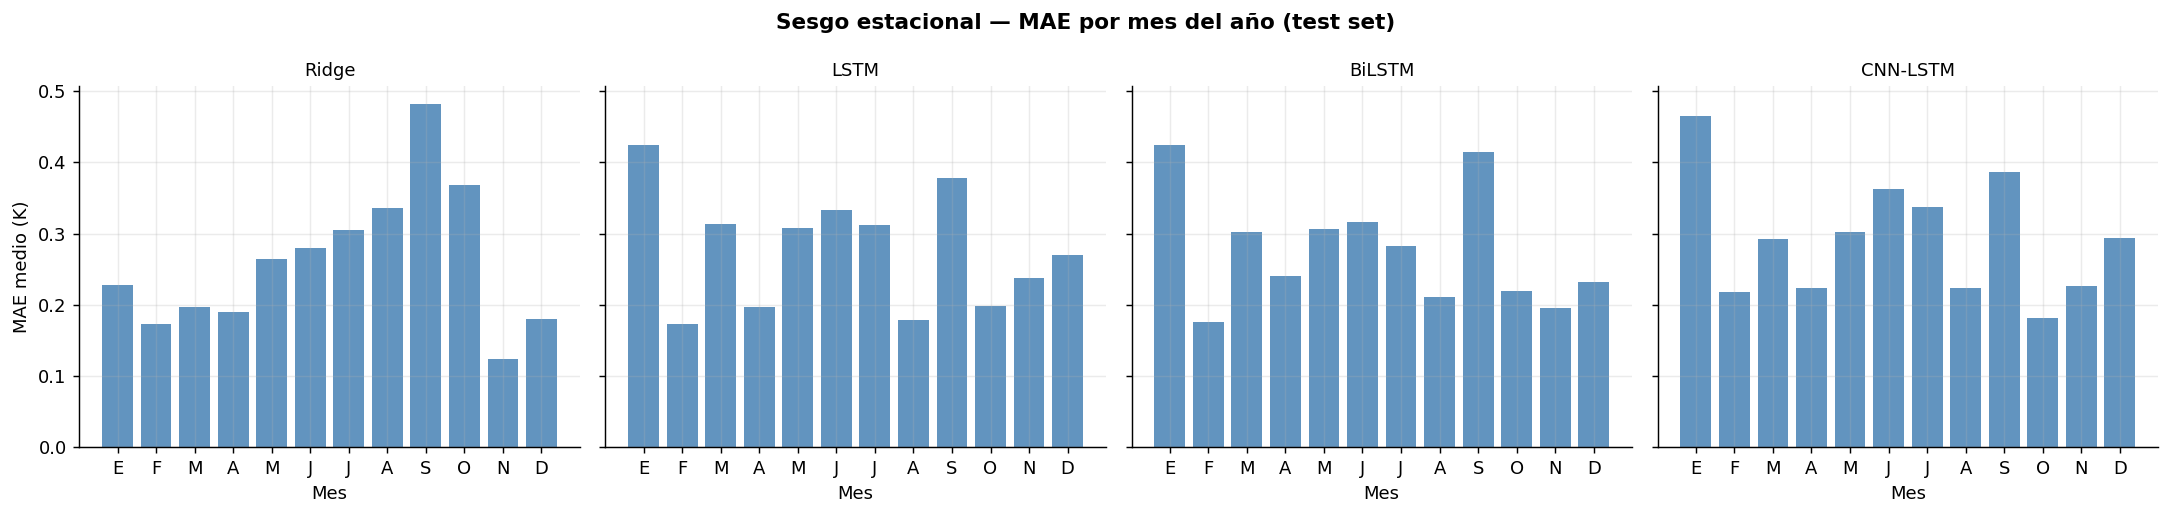

In [17]:
estac_nombres = [n for n in ["Ridge","XGBoost","LSTM","BiLSTM","CNN-LSTM"]
                 if n in preds]

fig, axes = plt.subplots(1, len(estac_nombres),
                         figsize=(4.2*len(estac_nombres), 4), sharey=True)
if len(estac_nombres) == 1: axes = [axes]
meses_lbl = ["E","F","M","A","M","J","J","A","S","O","N","D"]

for ax, nombre in zip(axes, estac_nombres):
    yt_r, yp_r, t_raw = preds[nombre]
    n = min(len(yt_r), len(yp_r))
    if (not isinstance(t_raw, pd.DatetimeIndex) or len(t_raw) < n):
        ax.set_title(f"{nombre}\n(sin índice de fechas)"); continue
    t_idx  = pd.DatetimeIndex(t_raw[:n])
    err    = np.abs(yp_r[:n] - yt_r[:n])
    meses  = t_idx.month
    mae_m  = [err[meses==m].mean() if (meses==m).any() else np.nan
              for m in range(1,13)]
    ax.bar(range(1,13), mae_m, color="steelblue", alpha=0.85)
    ax.set_xticks(range(1,13)); ax.set_xticklabels(meses_lbl)
    ax.set_title(nombre, fontsize=10); ax.set_xlabel("Mes")

axes[0].set_ylabel("MAE medio (K)")
fig.suptitle("Sesgo estacional — MAE por mes del año (test set)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(EVAL_DIR / "sesgo_estacional.png", dpi=150)
plt.show()

## 12. Resumen ejecutivo

In [18]:
df_resumen = df_eval.merge(
    df_gap[["Modelo","Val-ACC","Brecha Val→Test","Confiabilidad"]], on="Modelo", how="left"
).merge(
    df_dw[["Modelo","DW","Autocorr"]], on="Modelo", how="left"
)
df_resumen.to_csv(EVAL_DIR / "resumen_ejecutivo.csv", index=False)

print("="*72)
print("  RESUMEN EJECUTIVO — Evaluación ERA5 T2M Caribe")
print(f"  horizon={HORIZON}m | n_lags_seq={N_LAGS}")
print(f"  Test: {td_test[0].date()} → {td_test[-1].date()}")
print("="*72)

aptos = df_resumen[
    (df_resumen["Confiabilidad"].isin(["Alta","Media"])) &
    (df_resumen["ACC"] > 0.6)
].sort_values("ACC", ascending=False)

print("\nMODELOS CON SKILL OPERACIONAL (ACC>0.6, confiabilidad ≥ Media):")
for _, row in aptos.iterrows():
    dw_s = f" DW={row['DW']:.2f}" if pd.notna(row.get("DW")) else ""
    print(f"{row['Modelo']:<18} ACC={row['ACC']:.3f} {row['IC 95% ACC']}"
          f"  RMSE={row['RMSE (K)']:.3f}K  {row['Confiabilidad']}{dw_s}")

excluir = df_resumen[
    (df_resumen["Confiabilidad"]=="Baja ✗") | (df_resumen["ACC"]<=0.6)
]
print("\nMODELOS A EXCLUIR:")
for _, row in excluir.iterrows():
    why = []
    if row["ACC"] <= 0.6: why.append(f"ACC={row['ACC']:.3f}")
    if row["Confiabilidad"]=="Baja": why.append(f"Brecha={row['Brecha Val→Test']:+.2f}")
    print(f" {row['Modelo']:<18} {' | '.join(why)}")

print("\nHALLAZGOS DW:")
alta_ac = df_dw[df_dw["Autocorr"]=="Alta"]["Modelo"].tolist()
if alta_ac:
    print(f"  Autocorrelación residual alta en: {alta_ac}")
    print(f"  Causa probable: ventana ciega de {HORIZON}m")
    print(f"  Solución: añadir y(t-1)…y(t-{HORIZON}) como features")

print("\nARCHIVOS GENERADOS:")
for fp in sorted(EVAL_DIR.iterdir()):
    print(f"  {fp.name}")
print("="*72)

  RESUMEN EJECUTIVO — Evaluación ERA5 T2M Caribe
  horizon=3m | n_lags_seq=24
  Test: 2021-01-01 → 2025-12-01

MODELOS CON SKILL OPERACIONAL (ACC>0.6, confiabilidad ≥ Media):
Ridge              ACC=0.778 [0.683, 0.861]  RMSE=0.361K  Alta DW=0.52
Lasso              ACC=0.769 [0.668, 0.855]  RMSE=0.468K  Media
BiLSTM             ACC=0.753 [0.646, 0.830]  RMSE=0.344K  Media DW=0.96
MLP                ACC=0.743 [0.644, 0.829]  RMSE=0.383K  Alta
TCN                ACC=0.742 [0.636, 0.822]  RMSE=0.351K  Media DW=0.96
CNN-LSTM           ACC=0.739 [0.624, 0.824]  RMSE=0.368K  Media DW=0.85
Persistence        ACC=0.736 [0.618, 0.823]  RMSE=0.375K  Media

MODELOS A EXCLUIR:
 Climatología       ACC=0.000

HALLAZGOS DW:
  Autocorrelación residual alta en: ['Ridge', 'LSTM', 'BiLSTM', 'CNN-LSTM', 'TCN']
  Causa probable: ventana ciega de 3m
  Solución: añadir y(t-1)…y(t-3) como features

ARCHIVOS GENERADOS:
  brecha_val_test.csv
  brecha_val_test.png
  diagnostico_residuos.csv
  diagnostico_residuos